In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
legs = 4
samples = 50
steps = 3
print(f"{(legs*samples)**steps:,d}")

8,000,000


**Reward Kernel.** Tracking errors pass through a bounded logistic kernel instead of a squared norm, so a large early error never makes falling the cheapest option:

$$
K(x) = \frac{1}{e^{x} + 2 + e^{-x}}, \quad K \in (0, 0.25], \text{ maximal at } x = 0
$$

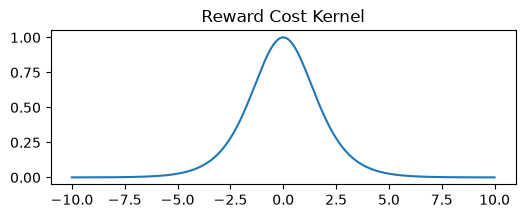

In [2]:
# Kernel from the Rewards.
# We actually use K'(x) = K(4x) here
def K(x, s=1.0): return 4/(np.exp(s*x)+2+np.exp(-s*x))

xs = np.linspace(-10, 10, 10_000)
dx = xs[1]-xs[0]

# ========================
plt.figure(figsize=(6,2))
plt.title("Reward Cost Kernel")
plt.plot(xs, K(xs), label="K(x)")


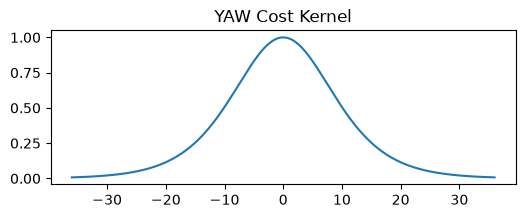

In [4]:
xs = np.linspace(-np.pi/5, np.pi/5, 10_000)


# ========================
plt.figure(figsize=(6,2))
plt.title("YAW Cost Kernel")
plt.plot(xs/np.pi*180, K(xs,10), label="K(x)")

**Gait Pattern.**


In [ ]:
# LF, LB, RB, RF (match your foot order)
OFFSETS = np.array([0.5, 0.75, 0.25, 0.0])  
DUTY = 0.75 + 0.01 

leg_phase = (phase + OFFSETS) % 1.0
desired_stance = leg_phase < DUTY

[14 14 14 14]


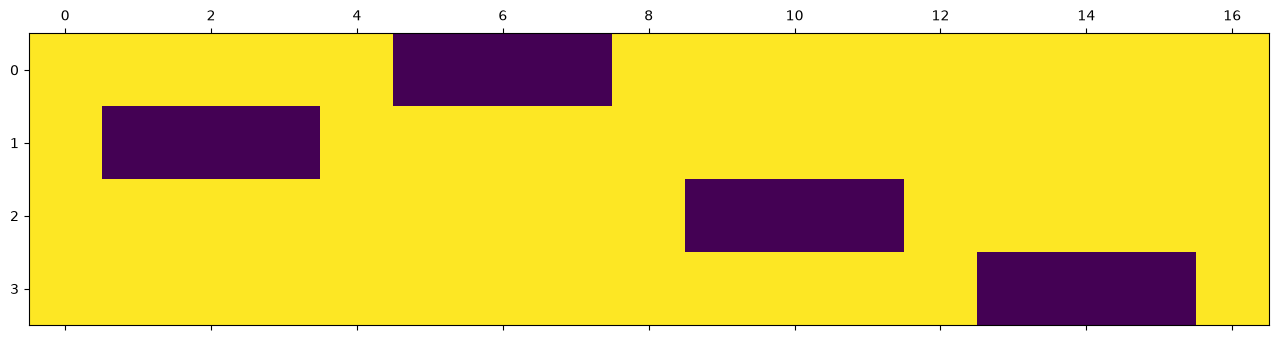

In [ ]:
# LF, LB, RB, RF (match your foot order)
OFFSETS = np.array([0.5, 0.75, 0.25, 0.0])  
DUTY = 0.75 + 0.01 

phase = np.linspace(0,1,16+1)
leg_phase = (phase[:,None] + OFFSETS) % 1.0
desired_stance = leg_phase < DUTY

print(desired_stance.sum(0))

plt.matshow(desired_stance.T)

# def crawl_contact_reward(phase, contacts, foot_forces, foot_vels):
#     # phase: (N,) in [0,1); contacts: (N,4) bool; foot_forces/foot_vels: (N,4)
#     leg_phase = (phase.unsqueeze(1) + OFFSETS) % 1.0
#     desired_stance = leg_phase < DUTY               # (N,4)

#     # penalize force during swing, foot velocity during stance
#     swing_force = (~desired_stance) * (1 - torch.exp(-foot_forces**2 / 100.0))
#     stance_vel  = desired_stance   * (1 - torch.exp(-foot_vels**2 / 2.0))
#     return -(swing_force + stance_vel).sum(dim=1)   # or use +match count